In [1]:
import matplotlib.pyplot as plt
# %matplotlib widget

import os
import pandas as pd
import numpy as np

In [2]:
data_root_folder = os.path.expanduser("~/genSecSysId-Data/data/SilverboxFiles/")
file_name = 'SNLS80mV.csv'

         V1        V2  Unnamed: 2
0  0.005776  0.009398         NaN
1  0.006610  0.012971         NaN
2  0.005958  0.010825         NaN
3  0.005732  0.004072         NaN
4  0.006398 -0.003965         NaN
Input shape: (131072, 1)
Output shape: (131072, 1)


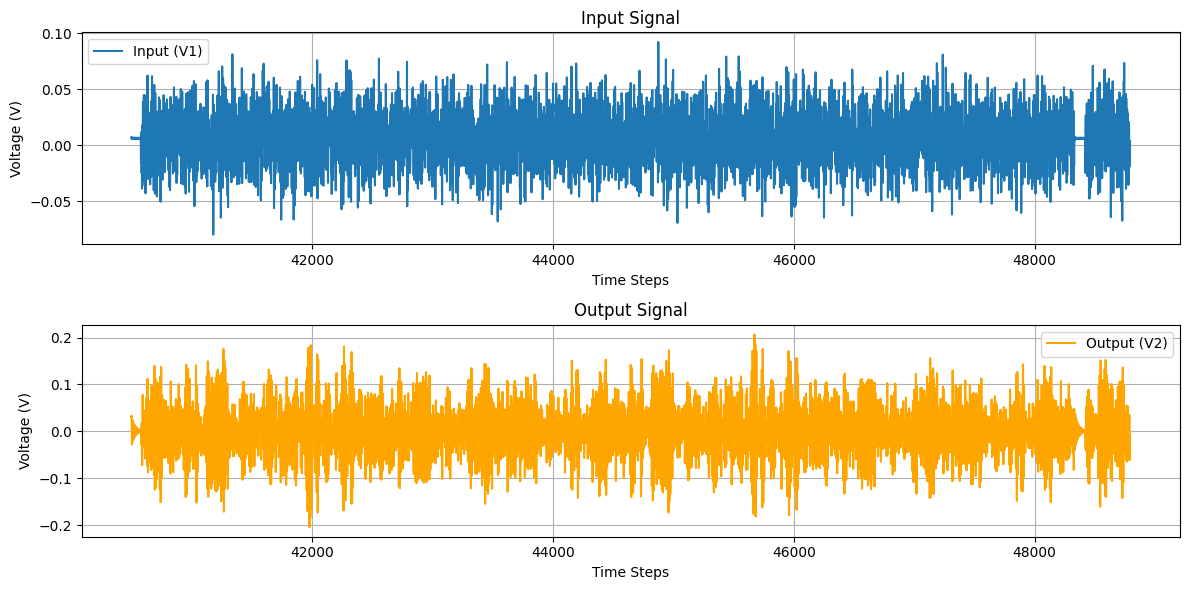

In [3]:


data_path = os.path.join(data_root_folder, file_name)
data = pd.read_csv(data_path)
print(data.head())
input_names = ['V1']
output_names = ['V2']

u = data[input_names].values
y = data[output_names].values
print("Input shape:", u.shape)
print("Output shape:", y.shape)



N1 = 40500
N2 = N1 + 8192

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)

plt.plot(np.linspace(N1, N2+100, N2 - N1+ 1000), u[N1:N2+1000], label='Input (V1)')
plt.title('Input Signal')
plt.xlabel('Time Steps')
plt.ylabel('Voltage (V)')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(np.linspace(N1, N2+100, N2 - N1+ 1000), y[N1:N2+1000], label='Output (V2)', color='orange')
plt.title('Output Signal')
plt.xlabel('Time Steps')
plt.ylabel('Voltage (V)')
plt.legend() 
plt.grid()
plt.tight_layout()
plt.show()

Subsequences shape (input): (77, 1688, 1)
Subsequences shape (output): (77, 1688, 1)


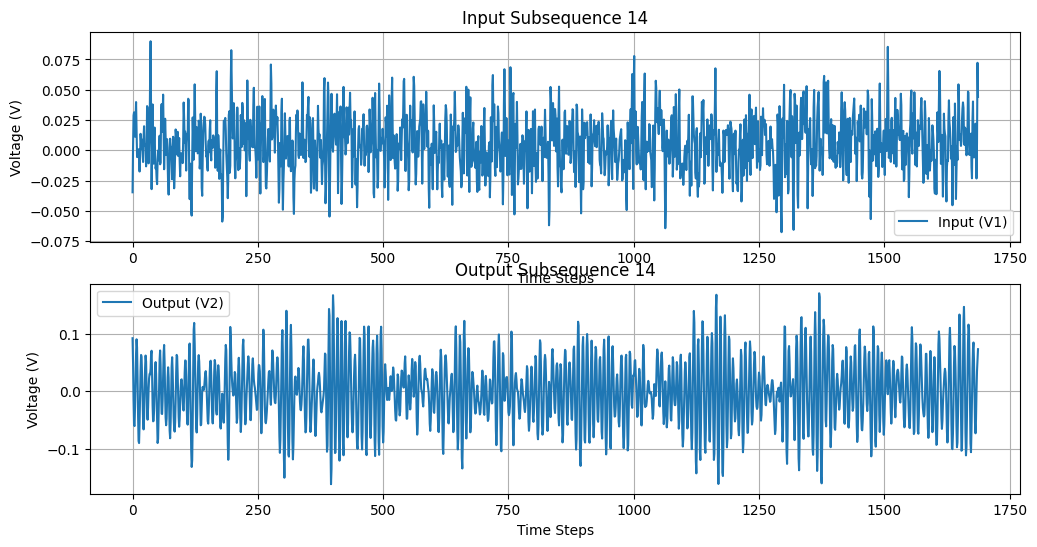

In [7]:
N = u.shape[0]
T = 8192
N_s = T//5 + 50 # length of subsequences
# split data into subsequences
def split_into_subsequences(data, N_s):
    N = data.shape[0]
    subsequences = []
    for start in range(0, N - N_s + 1, N_s):
        end = start + N_s
        subsequences.append(data[start:end])
    return np.array(subsequences)

u_subseq = split_into_subsequences(u, N_s)
y_subseq = split_into_subsequences(y, N_s)

print("Subsequences shape (input):", u_subseq.shape)
print("Subsequences shape (output):", y_subseq.shape)

# plot random subequence
idx = np.random.randint(0, u_subseq.shape[0])
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(u_subseq[idx], label='Input (V1)')
plt.title(f'Input Subsequence {idx}')
plt.xlabel('Time Steps')
plt.ylabel('Voltage (V)')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)        
plt.plot(y_subseq[idx], label='Output (V2)')
plt.title(f'Output Subsequence {idx}')
plt.xlabel('Time Steps')
plt.ylabel('Voltage (V)')
plt.grid()
plt.legend()





In [8]:
# save each subsequence as individual csv file
output_folder = os.path.join(data_root_folder, "raw")
os.makedirs(output_folder, exist_ok=True)
for i in range(u_subseq.shape[0]):
    subseq_data = pd.DataFrame({
        'V1': u_subseq[i].flatten(),
        'V2': y_subseq[i].flatten()
    })
    subseq_file_name = f"subsequence_{i}.csv"
    subseq_data.to_csv(os.path.join(output_folder, subseq_file_name), index=False)
print(f"Saved {u_subseq.shape[0]} subsequences to {output_folder}")

Saved 77 subsequences to /Users/jack/genSecSysId-Data/data/SilverboxFiles/raw


In [9]:
# split raw files from output_folder into train/val/test folder in subfolder "prepared"
prepared_folder = os.path.join(data_root_folder, "prepared")
train_folder = os.path.join(prepared_folder, "train")
val_folder = os.path.join(prepared_folder, "validation")
test_folder = os.path.join(prepared_folder, "test")
os.makedirs(train_folder, exist_ok=True)
os.makedirs(val_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True) 
subseq_files = sorted([f for f in os.listdir(output_folder) if f.endswith('.csv')])
num_files = len(subseq_files)
train_end = int(0.7 * num_files)
val_end = int(0.8 * num_files)
for i, file_name in enumerate(subseq_files):
    src_path = os.path.join(output_folder, file_name)
    if i < train_end:
        dst_path = os.path.join(train_folder, file_name)
    elif i < val_end:
        dst_path = os.path.join(val_folder, file_name)
    else:
        dst_path = os.path.join(test_folder, file_name)
    os.rename(src_path, dst_path)
print(f"Split {num_files} subsequences into train/val/test folders in {prepared_folder}")

Split 77 subsequences into train/val/test folders in /Users/jack/genSecSysId-Data/data/SilverboxFiles/prepared
